 # Deep Learning - Assignment 3
 ## Lyrics Generation using RNNs

 **Student Names:** Yuriy Rusanov, Elad Orpaz

 **ID(s):** 340915149, 206216517

In [23]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import matplotlib.pyplot as plt
import pretty_midi
import os
import re
import random
from tqdm import tqdm
from gensim.models import Word2Vec
import torch.nn.functional as F

In [24]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

PyTorch Version: 2.5.1
CUDA Available: True


## 1. Data Loading and Preprocessing

In [25]:
LYRICS_TRAIN_CSV = 'data/lyrics_train_set.csv'
LYRICS_TEST_CSV = 'data/lyrics_test_set.csv'
MIDI_DIR = 'data/midi_files'
SIMPLE_FEATS_CSV = 'data/lyrics_midi_features.csv'
ADV_FEATS_CSV = 'data/advanced_melody_features.csv'

problem_songs = [
        'Beastie_Boys_-_Girls.mid',
        "Billy_Joel_-_Movin'_Out.mid",
        'Billy_Joel_-_Pressure.mid',
        'Dan_Fogelberg_-_Leader_of_the_Band.mid',
        'Brian_McKnight_-_On_The_Down_Low.mid',
        'Aaron_Neville_-_Tell_It_Like_It_Is.mid'
    ]

In [26]:
def load_lyrics_data(path):
    df = pd.read_csv(path, header=None, usecols=[0, 1, 2], names=['artist', 'song', 'lyrics'])
    df['artist_norm'] = (df['artist']
                         .str.strip().str.lower().str.replace(r'\s+', '_', regex=True))
    df['song_norm'] = (df['song']
                       .str.strip().str.lower().str.replace(r'\s+', '_', regex=True))
    return df


train_df = load_lyrics_data(LYRICS_TRAIN_CSV)
test_df = load_lyrics_data(LYRICS_TEST_CSV)

In [27]:
def extract_simple_midi_features(midi_path):
    try:
        pm = pretty_midi.PrettyMIDI(midi_path)
    except OSError as e:
        print(f"Skipping {midi_path!r}: {e}")
        return None
    tempos = pm.get_tempo_changes()[1]
    feats = {
        'tempo': float(np.mean(tempos)) if tempos.size > 0 else 120.0
    }
    notes = [(n.pitch, n.end - n.start, n.velocity)
             for inst in pm.instruments for n in inst.notes]
    if notes:
        P, D, V = zip(*notes)
        P = np.array(P);
        D = np.array(D);
        V = np.array(V)
        feats.update({
            'avg_pitch': float(P.mean()),
            'pitch_std': float(P.std()),
            'pitch_range': int(P.max() - P.min()),
            'avg_duration': float(D.mean()),
            'avg_velocity': float(V.mean()),
            'note_density': float(len(notes) / pm.get_end_time())
        })
    return feats


def build_or_load_simple_feats(df, midi_dir, out_csv):
    if os.path.exists(out_csv):
        return pd.read_csv(out_csv)
    rows = []
    files = os.listdir(midi_dir)
    for song in problem_songs:
        files.remove(song)

    for _, r in tqdm(df.iterrows(), total=len(df), desc="Simple MIDI feats"):
        aid, sid = r['artist_norm'], r['song_norm']
        for fn in files:
            if aid in fn.lower() and sid in fn.lower():
                feats = extract_simple_midi_features(os.path.join(midi_dir, fn))
                feats.update({'artist_norm': aid, 'song_norm': sid})
                rows.append(feats)
                break
    sdf = pd.DataFrame(rows)
    sdf.to_csv(out_csv, index=False)
    return sdf


# Load or create simple features
simple_feats_df = build_or_load_simple_feats(
    pd.concat([train_df, test_df]), MIDI_DIR, SIMPLE_FEATS_CSV)

print(f"Found matching MIDI files for {len(simple_feats_df)} songs")

Simple MIDI feats:   0%|          | 1/605 [00:00<01:08,  8.86it/s]C:\Users\forgedRice\anaconda3\envs\DRL\lib\site-packages\pretty_midi\pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
Simple MIDI feats: 100%|██████████| 605/605 [00:40<00:00, 15.05it/s]

Found matching MIDI files for 599 songs


In [33]:
def estimate_word_durations(tokens, total_dur, overhead=0.1):
    total_letters = sum(len(w) for w in tokens)
    tot_ov = overhead * len(tokens)
    t_per_letter = ((total_dur - tot_ov) / total_letters) if total_letters > 0 else 0
    times = []
    cur = 0.0
    for w in tokens:
        d = len(w) * t_per_letter + overhead
        times.append((w, cur, cur + d))
        cur += d
    if cur > 0:
        scale = total_dur / cur
        times = [(w, s * scale, e * scale) for w, s, e in times]
    return times


def extract_time_based_features(pm, word_times, ctx_win=1.0):
    out = []
    for w, s, e in word_times:
        feat = {'local_notes': [], 'context_before': [], 'context_after': []}
        for inst in pm.instruments:
            for n in inst.notes:
                if n.start < e and n.end > s:
                    feat['local_notes'].append((n.pitch, n.velocity, n.end - n.start))
                if n.end <= s and n.end > s - ctx_win:
                    feat['context_before'].append((n.pitch, n.velocity, s - n.end))
                if n.start >= e and n.start < e + ctx_win:
                    feat['context_after'].append((n.pitch, n.velocity, n.start - e))
        ln = feat['local_notes']
        if ln:
            P = np.array([p for p, _, _ in ln])
            D = np.array([d for _, _, d in ln])
            V = np.array([v for _, v, _ in ln])
            feat.update({
                'pitch_mean': float(P.mean()),
                'pitch_std': float(P.std()) if len(P) > 1 else 0.0,
                'velocity_mean': float(V.mean()),
                'duration_mean': float(D.mean()),
                'note_density': len(ln) / (e - s) if e > s else 0.0
            })
        else:
            feat.update({k: 0.0 for k in ['pitch_mean', 'pitch_std',
                                          'velocity_mean', 'duration_mean', 'note_density']})
        out.append((w, feat,
                    len(feat['local_notes']),
                    len(feat['context_before']),
                    len(feat['context_after'])))
    return out


def build_or_load_adv_feats(df, midi_dir, out_csv):
    if os.path.exists(out_csv):
        return pd.read_csv(out_csv)
    rows = []
    files = os.listdir(midi_dir)
    for song in problem_songs:
        files.remove(song)
    for _, r in tqdm(df.iterrows(), total=len(df), desc="Adv MIDI feats"):
        aid, sid = r['artist_norm'], r['song_norm']
        for fn in files:
            if aid in fn.lower() and sid in fn.lower():
                pm = pretty_midi.PrettyMIDI(os.path.join(midi_dir, fn))
                lyrics = re.findall(r'\b\w+\b', str(r['lyrics']).lower())
                if not lyrics: break
                times = estimate_word_durations(lyrics, pm.get_end_time())
                feats = extract_time_based_features(pm, times)
                for idx, (w, ft, nl, cb, ca) in enumerate(feats):
                    rows.append({
                        'artist_norm': aid,
                        'song_norm': sid,
                        'word_idx': idx,
                        'word': w,
                        'pitch_mean': ft['pitch_mean'],
                        'pitch_std': ft['pitch_std'],
                        'velocity_mean': ft['velocity_mean'],
                        'duration_mean': ft['duration_mean'],
                        'note_density': ft['note_density'],
                        'n_local_notes': nl,
                        'n_context_before': cb,
                        'n_context_after': ca
                    })
                break
    adf = pd.DataFrame(rows)
    adf.to_csv(out_csv, index=False)
    return adf


adv_feats_df = build_or_load_adv_feats(
    pd.concat([train_df, test_df]), MIDI_DIR, ADV_FEATS_CSV)


In [35]:
# Process lyrics and build vocabulary
def preprocess_lyrics(series):
    all_lyrics = []
    for lyric in series:
        lyric = str(lyric).lower()
        lines = lyric.split('&')
        for line in lines:
            tokens = re.findall(r'\b\w+\b', line)
            if tokens:  # Skip empty lines
                all_lyrics.append(tokens)
    return all_lyrics

# Process train lyrics
train_tokenized = preprocess_lyrics(train_df['lyrics'])
print(f"Number of lines in training set: {len(train_tokenized)}")

# Build vocabulary
def build_vocabulary(tokenized_lyrics, min_freq=2):
    word_counts = Counter()
    for line in tokenized_lyrics:
        word_counts.update(line)

    vocab = {'<PAD>': 0, '<UNK>': 1, '<START>': 2, '<END>': 3}
    idx = 4

    for word, count in word_counts.items():
        if count >= min_freq:
            vocab[word] = idx
            idx += 1

    return vocab, word_counts

vocab, word_counts = build_vocabulary(train_tokenized)
print(f"Vocabulary size: {len(vocab)}")
print(f"Top 10 most common words: {word_counts.most_common(10)}")

Number of lines in training set: 23860
Vocabulary size: 4033
Top 10 most common words: [('i', 7259), ('you', 6902), ('the', 5846), ('to', 3776), ('and', 3701), ('a', 3094), ('it', 2995), ('me', 2830), ('s', 2385), ('my', 2177)]


In [36]:
# Train Word2Vec model
print("Training custom Word2Vec model on lyrics dataset...")
embedding_dim = 300
window_size = 5
min_count = 1
workers = 4

custom_w2v_model = Word2Vec(
    sentences=train_tokenized,
    vector_size=embedding_dim,
    window=window_size,
    min_count=min_count,
    workers=workers,
    sg=1,
    epochs=20
)

print(f"Custom Word2Vec model trained with vector size: {custom_w2v_model.vector_size}")
print(f"Vocabulary size in Word2Vec model: {len(custom_w2v_model.wv.key_to_index)}")

# Create embedding matrix
def create_embedding_matrix(vocab, embedding_model, embedding_dim=300):
    embedding_matrix = np.zeros((len(vocab), embedding_dim))
    for word, idx in vocab.items():
        if word in embedding_model.wv:
            embedding_matrix[idx] = embedding_model.wv[word]
        elif word not in ['<PAD>', '<UNK>', '<START>', '<END>'] and word.lower() in embedding_model.wv:
            embedding_matrix[idx] = embedding_model.wv[word.lower()]

    # Initialize special tokens with random values
    for special_token in ['<UNK>', '<START>', '<END>']:
        embedding_matrix[vocab[special_token]] = np.random.uniform(-0.25, 0.25, embedding_dim)

    return embedding_matrix

embedding_matrix = create_embedding_matrix(vocab, custom_w2v_model)
print(f"Embedding matrix shape: {embedding_matrix.shape}")


Training custom Word2Vec model on lyrics dataset...
Custom Word2Vec model trained with vector size: 300
Vocabulary size in Word2Vec model: 7205
Embedding matrix shape: (4033, 300)


In [37]:
# Create datasets
class SimpleLyricsMelodyDataset(Dataset):
    def __init__(self, features_df, vocab):
        self.features_df = features_df
        self.vocab = vocab
        self.data = self.prepare_data()

    def prepare_data(self):
        data = []
        for _, row in self.features_df.iterrows():
            # Find corresponding lyrics
            if row['artist_norm'] in train_df['artist_norm'].values and row['song_norm'] in train_df['song_norm'].values:
                lyrics_row = train_df[
                    (train_df['artist_norm'] == row['artist_norm']) &
                    (train_df['song_norm'] == row['song_norm'])
                ]
                if len(lyrics_row) > 0:
                    lyrics = str(lyrics_row.iloc[0]['lyrics']).lower()
                    lines = lyrics.split('&')

                    for line in lines:
                        tokens = re.findall(r'\b\w+\b', line)
                        if len(tokens) < 2:  # Skip very short lines
                            continue

                        # Add start token if not present
                        if tokens[0] != '<START>':
                            tokens = ['<START>'] + tokens

                        # Convert to indices
                        indices = [self.vocab.get(token, self.vocab['<UNK>']) for token in tokens]

                        # Create input-target pairs
                        for i in range(len(indices) - 1):
                            input_word = indices[i]
                            target_word = indices[i + 1]

                            # Extract melody features
                            melody_feats = np.array([
                                row.get('avg_pitch', 0),
                                row.get('pitch_std', 0),
                                row.get('pitch_range', 0),
                                row.get('avg_duration', 0),
                                row.get('avg_velocity', 0),
                                row.get('note_density', 0),
                                row.get('tempo', 120) / 120.0,
                            ])

                            data.append({
                                'input_word': input_word,
                                'melody_features': melody_feats,
                                'target_word': target_word
                            })

        return data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        return {
            'input_word': torch.tensor(item['input_word'], dtype=torch.long),
            'melody_features': torch.tensor(item['melody_features'], dtype=torch.float),
            'target_word': torch.tensor(item['target_word'], dtype=torch.long),
        }

class AdvancedLyricsMelodyDataset(Dataset):
    def __init__(self, adv_df, vocab, context_size=3):
        self.vocab = vocab
        self.context_size = context_size
        # Group by song
        self.samples = []

        # Process data
        grouped = adv_df.groupby(['artist_norm', 'song_norm'])
        for (artist, song), group in grouped:
            # Sort by word index
            group = group.sort_values('word_idx')
            words = group['word'].tolist()

            # Extract features
            feats = group[[
                'pitch_mean', 'pitch_std', 'velocity_mean',
                'duration_mean', 'note_density',
                'n_local_notes', 'n_context_before', 'n_context_after'
            ]].values.astype(np.float32)

            # Convert words to indices
            indices = [vocab.get(w, vocab['<UNK>']) for w in words]

            # Create samples with context
            for i in range(self.context_size, len(words)):
                context_indices = indices[i-self.context_size:i]
                target_index = indices[i]
                context_features = feats[i-self.context_size:i]
                target_feature = feats[i]

                self.samples.append((
                    torch.tensor(context_indices, dtype=torch.long),
                    torch.tensor(context_features, dtype=torch.float),
                    torch.tensor(target_index, dtype=torch.long),
                    torch.tensor(target_feature, dtype=torch.float)
                ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        ctx_ids, ctx_feats, tgt_id, tgt_feat = self.samples[i]
        return {
            'context_words': ctx_ids,
            'context_features': ctx_feats,
            'target_word': tgt_id,
            'target_features': tgt_feat.unsqueeze(0)  # Add batch dimension
        }


## 5. Model Definition - First Approach (Simple Melody Integration)

In [38]:
# Define Models
class LyricsMelodyGeneratorSimple(nn.Module):
    def __init__(self, vocab_size, embedding_dim, melody_dim, hidden_dim,
                 num_layers, dropout, pretrained_embeddings):
        super(LyricsMelodyGeneratorSimple, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Word embeddings
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings))

        # Melody feature projection
        self.melody_projection = nn.Linear(melody_dim, embedding_dim)

        # LSTM layer
        self.lstm = nn.LSTM(embedding_dim * 2, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)

        # Output layer
        self.fc = nn.Linear(hidden_dim, vocab_size)

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, word_input, melody_features, hidden=None):
        # Get embeddings
        word_emb = self.embedding(word_input)  # [batch_size, emb_dim]

        # Project melody features to embedding dimension
        melody_emb = self.melody_projection(melody_features)  # [batch_size, emb_dim]

        # Concatenate word and melody embeddings
        combined_input = torch.cat([word_emb, melody_emb], dim=1).unsqueeze(1)  # [batch_size, 1, emb_dim*2]

        # Pass through LSTM
        if hidden is None:
            lstm_out, hidden = self.lstm(combined_input)
        else:
            lstm_out, hidden = self.lstm(combined_input, hidden)

        # Apply dropout and project to vocabulary size
        output = self.dropout(lstm_out.squeeze(1))
        output = self.fc(output)

        return output, hidden

    def init_hidden(self, batch_size, device):
        return (torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device),
                torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device))

    def generate_lyrics(self, melody_features, reverse_vocab, max_length=50,
                        start_word='<START>', temperature=1.0, device='cpu'):
        """Generate lyrics given melody features."""
        self.eval()
        words = [start_word]
        hidden = None

        word_input = torch.tensor([self.vocab[start_word]]).to(device)
        melody_feat_tensor = torch.tensor(melody_features, dtype=torch.float).unsqueeze(0).to(device)

        for _ in range(max_length):
            output, hidden = self.forward(word_input, melody_feat_tensor, hidden)

            # Apply temperature scaling
            output = output.div(temperature)

            # Convert to probabilities
            word_weights = output.squeeze().exp()

            # Sample from distribution
            word_idx = torch.multinomial(word_weights, 1)[0].item()

            # Convert to word
            word = reverse_vocab.get(word_idx, '<UNK>')

            # End sequence if end token or period
            if word == '<END>':
                break

            words.append(word)

            # Update input for next iteration
            word_input = torch.tensor([word_idx]).to(device)

        return words

In [39]:
# Define Advanced Model
def sample_top_k(logits, k=50, temperature=1.0):
    """Return 1 index sampled from the top‑k filtered distribution."""
    logits = logits / temperature
    top_logits, top_idx = torch.topk(logits, k)
    probs = F.softmax(top_logits, dim=-1)
    choice = torch.multinomial(probs, 1)
    return top_idx[choice]

def sample_top_p(logits, p=0.9, temperature=1.0):
    """Return 1 index sampled from top‑p (nucleus) distribution."""
    logits = logits / temperature
    sorted_logits, sorted_idx = torch.sort(logits, descending=True)
    probs = F.softmax(sorted_logits, dim=-1)
    cumulative = probs.cumsum(dim=-1)
    mask = cumulative > p
    if mask.any():  # Check if any True values exist
        if mask[0]:  # Ensure at least one token is kept
            mask[0] = False
        sorted_logits[mask] = -float("Inf")
    filtered_probs = F.softmax(sorted_logits, dim=-1)
    choice = torch.multinomial(filtered_probs, 1)
    return sorted_idx[choice]

class LyricsMelodyGeneratorAdvanced(nn.Module):
    def __init__(self, vocab_size, embedding_dim, feature_dim, hidden_dim,
                 context_size, num_layers, dropout, pretrained_embeddings, vocab):
        super(LyricsMelodyGeneratorAdvanced, self).__init__()

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.feature_dim = feature_dim
        self.hidden_dim = hidden_dim
        self.context_size = context_size
        self.num_layers = num_layers
        self.vocab = vocab  # Store the vocabulary

        # Word embeddings
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings))

        # Feature encoder (for musical features)
        self.feature_encoder = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # LSTM for sequence modeling
        # Input: word embeddings + music features for each context word
        lstm_input_dim = embedding_dim + (hidden_dim // 2)
        self.lstm = nn.LSTM(
            input_size=lstm_input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Attention layer for context words
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads=4, batch_first=True)

        # Calculate the actual dimension after concatenation
        # final hidden state + attention output + target features
        final_dim = hidden_dim + hidden_dim + (hidden_dim // 2)

        # Output layer with the correct input dimension
        self.fc = nn.Sequential(
            nn.Linear(final_dim, hidden_dim),  # Use the actual dimension
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, vocab_size)
        )

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, context_words, context_features, target_features=None):
        batch_size = context_words.size(0)

        # Word embeddings for context words [batch_size, context_size, embedding_dim]
        word_embeds = self.embedding(context_words)

        # Encode music features for context words [batch_size, context_size, hidden_dim//2]
        music_embeds = self.feature_encoder(context_features)

        # Concatenate word and music embeddings
        combined_input = torch.cat([word_embeds, music_embeds], dim=2)

        # Process with LSTM
        lstm_out, (h_n, c_n) = self.lstm(combined_input)

        # Apply self-attention to get better context representation
        attn_output, _ = self.attention(lstm_out, lstm_out, lstm_out)

        # Take the representation for the last word in context
        final_hidden = h_n[-1]  # [batch_size, hidden_dim]
        last_attn_output = attn_output[:, -1, :]  # [batch_size, hidden_dim]

        # Concatenate final hidden state with attention output
        final_repr = torch.cat([final_hidden, last_attn_output], dim=1)  # [batch_size, hidden_dim*2]

        # If target features provided, incorporate them
        if target_features is not None:
            target_music_embed = self.feature_encoder(target_features).squeeze(1)  # [batch_size, hidden_dim//2]
            # Use target music features in the final prediction
            final_repr = torch.cat([final_repr, target_music_embed],
                                   dim=1)  # [batch_size, hidden_dim*2 + hidden_dim//2]
        else:
            # During generation, we don't have target features, so use zeros
            dummy_features = torch.zeros(batch_size, self.hidden_dim // 2, device=context_words.device)
            final_repr = torch.cat([final_repr, dummy_features], dim=1)

        # Project to vocabulary size
        output = self.fc(final_repr)

        return output

    def extract_word_time_features(self, midi_data, start_time, end_time, ctx_win=1.0):
        """Extract features for a word at a specific time window."""
        features = {
            'local_notes': [],
            'pitch_mean': 0,
            'pitch_std': 0,
            'velocity_mean': 0,
            'note_density': 0,
            'duration_mean': 0,
            'context_before': [],
            'context_after': []
        }

        for instrument in midi_data.instruments:
            for note in instrument.notes:
                note_overlaps = (note.start < end_time) and (note.end > start_time)
                note_before = (note.end <= start_time) and (note.end > start_time - ctx_win)
                note_after = (note.start >= end_time) and (note.start < end_time + ctx_win)

                if note_overlaps:
                    features['local_notes'].append((
                        note.pitch,
                        note.velocity,
                        note.end - note.start
                    ))

                if note_before:
                    features['context_before'].append((
                        note.pitch,
                        note.velocity,
                        start_time - note.end
                    ))

                if note_after:
                    features['context_after'].append((
                        note.pitch,
                        note.velocity,
                        note.start - end_time
                    ))

        # Calculate aggregate features
        ln = features['local_notes']
        if ln:
            P = np.array([p for p,_,_ in ln])
            D = np.array([d for _,_,d in ln])
            V = np.array([v for _,v,_ in ln])

            features['pitch_mean'] = float(P.mean())
            features['pitch_std'] = float(P.std()) if len(P)>1 else 0.0
            features['velocity_mean'] = float(V.mean())
            features['duration_mean'] = float(D.mean())
            features['note_density'] = len(ln)/(end_time - start_time) if end_time > start_time else 0.0

        return features

    def create_feature_vector(self, features):
        """Create a standardized feature vector from extracted features."""
        return np.array([
            features['pitch_mean'] / 127.0 if features.get('local_notes') else 0.5,
            features['pitch_std'] / 12.0 if features.get('local_notes') else 0.0,
            features['velocity_mean'] / 127.0 if features.get('local_notes') else 0.5,
            features['duration_mean'] if features.get('local_notes') else 0.5,
            features['note_density'] if features.get('local_notes') else 0.0,
            len(features['local_notes']),
            len(features['context_before']),
            len(features['context_after'])
        ])

    def generate_lyrics(self, midi_data, reverse_vocab, max_length=50,
                        start_words=None, temperature=1.0, device='cpu', top_k=50, top_p=None):
        """
        Generate lyrics using the advanced model.
        """
        self.eval()

        if start_words is None:
            start_words = ['<START>'] * self.context_size
        elif len(start_words) < self.context_size:
            # Pad with START tokens if needed
            start_words = ['<START>'] * (self.context_size - len(start_words)) + start_words

        # Output sequence starts with the context words
        output_words = list(start_words)

        # Convert start words to indices
        context_indices = [self.vocab.get(w, self.vocab['<UNK>']) for w in start_words]
        context_tensor = torch.tensor([context_indices], dtype=torch.long).to(device)

        # Estimate timing for the sequence
        # Estimate timing for the sequence
        total_duration = midi_data.get_end_time()
        # Assuming the generation will be about 50 words
        estimated_word_count = max_length
        word_duration = total_duration / estimated_word_count

        # Initial context positions (start at beginning of the song)
        current_time = 0.0
        word_timings = [(word, current_time, current_time + word_duration)
                        for word in start_words]
        current_time += word_duration * len(start_words)

        # Extract features for the context words
        context_features_list = []
        for _, start_time, end_time in word_timings:
            features = self.extract_word_time_features(midi_data, start_time, end_time)
            feature_vector = self.create_feature_vector(features)
            context_features_list.append(feature_vector)

        context_features = torch.tensor([context_features_list], dtype=torch.float).to(device)

        # Generate words one by one
        for _ in range(max_length - len(start_words)):
            # No target features during generation (use None)
            with torch.no_grad():
                output = self.forward(context_tensor, context_features, None)

            logits = output.squeeze()

            # ------- SMART SAMPLING ------------------------------------
            if top_p is not None:
                word_idx = sample_top_p(logits, p=top_p,
                                        temperature=temperature).item()
            else:
                word_idx = sample_top_k(logits, k=top_k,
                                        temperature=temperature).item()

            # Convert to word
            word = reverse_vocab.get(word_idx, '<UNK>')

            # End sequence if end token or period
            if word == '<END>':
                break

            # Add to output
            output_words.append(word)

            # Update context for next iteration
            context_indices = context_indices[1:] + [word_idx]
            context_tensor = torch.tensor([context_indices], dtype=torch.long).to(device)

            # Update word timing and extract features
            next_timing = (word, current_time, current_time + word_duration)
            current_time += word_duration

            next_features = self.extract_word_time_features(midi_data, next_timing[1], next_timing[2])
            next_feature_vector = self.create_feature_vector(next_features)

            # Update context features
            context_features_list = context_features_list[1:] + [next_feature_vector]
            context_features = torch.tensor([context_features_list], dtype=torch.float).to(device)

        return output_words

 ## 6. Training Functions

In [40]:
# Training functions
def train_model(model, train_loader, val_loader, epochs, learning_rate, clip_grad, device):
    """Train the model."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

    # Training loop
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        # Training
        for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} - Training"):
            optimizer.zero_grad()

            input_words = batch['input_word'].to(device)
            melody_features = batch['melody_features'].to(device)
            targets = batch['target_word'].to(device)

            outputs, _ = model(input_words, melody_features)
            loss = criterion(outputs, targets)

            loss.backward()
            # Clip gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{epochs} - Validation"):
                input_words = batch['input_word'].to(device)
                melody_features = batch['melody_features'].to(device)
                targets = batch['target_word'].to(device)

                outputs, _ = model(input_words, melody_features)
                loss = criterion(outputs, targets)

                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Update learning rate
        scheduler.step(avg_val_loss)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model = model.state_dict().copy()
            print(f"New best model saved!")

    # Load best model
    if best_model is not None:
        model.load_state_dict(best_model)

    return model, train_losses, val_losses

In [41]:
def train_advanced_model(model, train_loader, val_loader, epochs, learning_rate, clip_grad, device):
    """Train the advanced model."""
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        # Training
        for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} - Training"):
            optimizer.zero_grad()

            context_words = batch['context_words'].to(device)
            context_features = batch['context_features'].to(device)
            target_word = batch['target_word'].to(device)
            target_features = batch['target_features'].to(device)

            outputs = model(context_words, context_features, target_features)
            loss = criterion(outputs, target_word)

            loss.backward()
            # Clip gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{epochs} - Validation"):
                context_words = batch['context_words'].to(device)
                context_features = batch['context_features'].to(device)
                target_word = batch['target_word'].to(device)
                target_features = batch['target_features'].to(device)

                outputs = model(context_words, context_features, target_features)
                loss = criterion(outputs, target_word)

                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Update learning rate
        scheduler.step(avg_val_loss)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model = model.state_dict().copy()
            print(f"New best model saved!")

    # Load best model
    if best_model is not None:
        model.load_state_dict(best_model)

    return model, train_losses, val_losses

In [42]:
# Create datasets from the features
print("Creating datasets...")

# Simple dataset
print("Creating Simple Dataset...")
simple_dataset = SimpleLyricsMelodyDataset(simple_feats_df, vocab)

# Split into train and validation
simple_train_size = int(0.8 * len(simple_dataset))
simple_val_size = len(simple_dataset) - simple_train_size
simple_train_dataset, simple_val_dataset = torch.utils.data.random_split(
    simple_dataset, [simple_train_size, simple_val_size])

# Create data loaders
simple_train_loader = DataLoader(simple_train_dataset, batch_size=64, shuffle=True)
simple_val_loader = DataLoader(simple_val_dataset, batch_size=64)

print(f"Simple Train dataset size: {len(simple_train_dataset)}")
print(f"Simple Validation dataset size: {len(simple_val_dataset)}")

# Advanced dataset
print("Creating Advanced Dataset...")
context_size = 16  # Number of context words
advanced_dataset = AdvancedLyricsMelodyDataset(adv_feats_df, vocab, context_size=context_size)

# Split into train and validation
adv_train_size = int(0.8 * len(advanced_dataset))
adv_val_size = len(advanced_dataset) - adv_train_size
adv_train_dataset, adv_val_dataset = torch.utils.data.random_split(
    advanced_dataset, [adv_train_size, adv_val_size])

# Create data loaders
adv_train_loader = DataLoader(adv_train_dataset, batch_size=64, shuffle=True)
adv_val_loader = DataLoader(adv_val_dataset, batch_size=64)

print(f"Advanced train dataset size: {len(adv_train_dataset)}")
print(f"Advanced validation dataset size: {len(adv_val_dataset)}")

Creating datasets...
Creating Simple Dataset...
Simple Train dataset size: 130441
Simple Validation dataset size: 32611
Creating Advanced Dataset...
Advanced train dataset size: 124104
Advanced validation dataset size: 31027


Initializing simple model...
Training simple model...


Epoch 1/10 - Validation: 100%|██████████| 510/510 [00:00<00:00, 872.12it/s]


Epoch 1/10, Train Loss: 6.0867, Val Loss: 6.0510
New best model saved!


Epoch 2/10 - Validation: 100%|██████████| 510/510 [00:00<00:00, 921.30it/s]


Epoch 2/10, Train Loss: 6.0186, Val Loss: 6.0519


...

Epoch 8/10, Train Loss: 5.9949, Val Loss: 6.0535


Epoch 9/10 - Validation: 100%|██████████| 510/510 [00:00<00:00, 885.88it/s]


Epoch 9/10, Train Loss: 5.9879, Val Loss: 6.0530


Epoch 10/10 - Validation: 100%|██████████| 510/510 [00:00<00:00, 869.13it/s]

Epoch 10/10, Train Loss: 5.9879, Val Loss: 6.0606


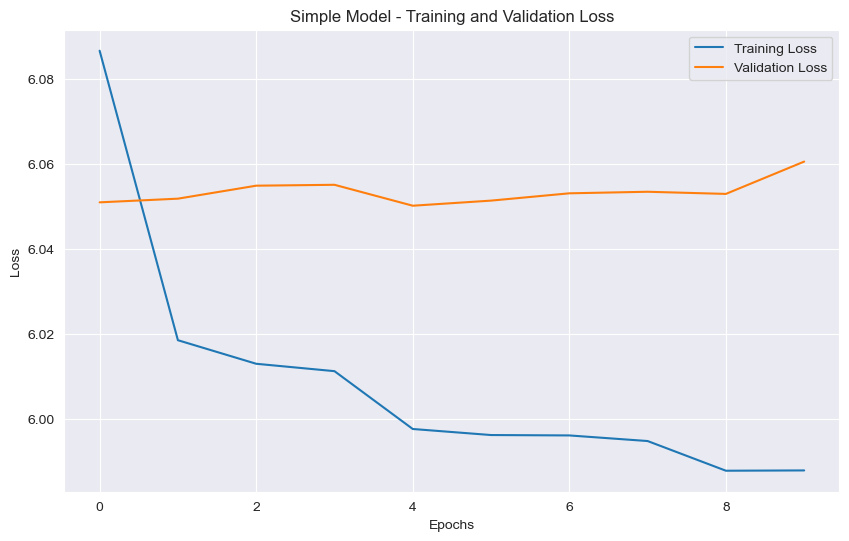

In [46]:
# Initialize simple model
print("Initializing simple model...")
vocab_size = len(vocab)
melody_dim = 7  # Number of simple melody features
hidden_dim = 256

simple_model = LyricsMelodyGeneratorSimple(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    melody_dim=melody_dim,
    hidden_dim=hidden_dim,
    num_layers=2,
    dropout=0.3,
    pretrained_embeddings=embedding_matrix
).to(device)

# Train simple model
print("Training simple model...")
trained_simple_model, simple_train_losses, simple_val_losses = train_model(
    model=simple_model,
    train_loader=simple_train_loader,
    val_loader=simple_val_loader,
    epochs=10,
    learning_rate=0.001,
    clip_grad=5.0,
    device=device
)

# Plot training and validation loss for simple model
plt.figure(figsize=(10, 6))
plt.plot(simple_train_losses, label='Training Loss')
plt.plot(simple_val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Simple Model - Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('simple_model_loss.png')
plt.show()
plt.close()

Initializing advanced model...
Training advanced model...


Epoch 1/20 - Validation: 100%|██████████| 485/485 [00:00<00:00, 550.62it/s]


Epoch 1/20, Train Loss: 5.8247, Val Loss: 5.1150
New best model saved!


Epoch 2/20 - Validation: 100%|██████████| 485/485 [00:00<00:00, 549.57it/s]


Epoch 2/20, Train Loss: 5.0496, Val Loss: 4.6933
New best model saved!


...

Epoch 18/20, Train Loss: 3.0867, Val Loss: 3.6592


Epoch 19/20 - Validation: 100%|██████████| 485/485 [00:01<00:00, 453.39it/s]


Epoch 19/20, Train Loss: 3.0474, Val Loss: 3.6513


Epoch 20/20 - Validation: 100%|██████████| 485/485 [00:01<00:00, 368.39it/s]


Epoch 20/20, Train Loss: 2.8833, Val Loss: 3.6354
New best model saved!


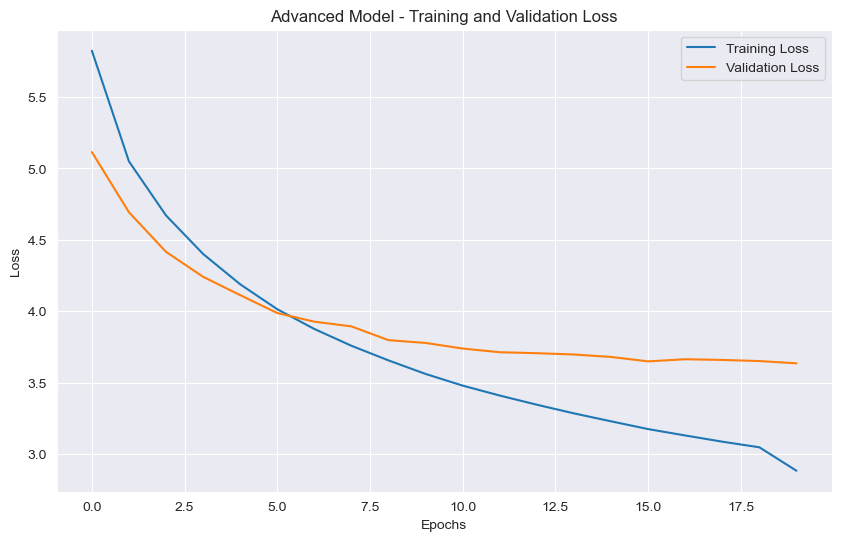

In [47]:
# Initialize advanced model
print("Initializing advanced model...")
feature_dim = 8  # Advanced feature vector size
hidden_dim = 256
num_layers = 2

advanced_model = LyricsMelodyGeneratorAdvanced(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    feature_dim=feature_dim,
    hidden_dim=hidden_dim,
    context_size=context_size,
    num_layers=num_layers,
    dropout=0.3,
    pretrained_embeddings=embedding_matrix,
    vocab=vocab
).to(device)

# Train advanced model
print("Training advanced model...")
trained_advanced_model, adv_train_losses, adv_val_losses = train_advanced_model(
    model=advanced_model,
    train_loader=adv_train_loader,
    val_loader=adv_val_loader,
    epochs=20,
    learning_rate=0.001,
    clip_grad=5.0,
    device=device
)

# Plot training and validation loss for advanced model
plt.figure(figsize=(10, 6))
plt.plot(adv_train_losses, label='Training Loss')
plt.plot(adv_val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Advanced Model - Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('advanced_model_loss.png')
plt.show()
plt.close()

In [48]:
# Save models
print("Saving models...")
torch.save({
    'model_state_dict': trained_simple_model.state_dict(),
    'vocab': vocab,
    'embedding_matrix': embedding_matrix
}, 'simple_lyrics_model.pth')

torch.save({
    'model_state_dict': trained_advanced_model.state_dict(),
    'vocab': vocab,
    'embedding_matrix': embedding_matrix
}, 'advanced_lyrics_model.pth')

Saving models...


In [ ]:
# Generation functions
def generate_lyrics_with_simple_model(model, melody_features, reverse_vocab,
                                     start_word='<START>', max_length=50,
                                     temperature=0.8, device='cpu'):
    """Generate lyrics using the simple model."""
    model.eval()

    # Initialize with start word
    words = [start_word]
    hidden = None

    # Convert start word to tensor
    word_input = torch.tensor([model.vocab[start_word]]
                             if hasattr(model, 'vocab')
                             else [vocab[start_word]],
                             dtype=torch.long).to(device)

    # Convert melody features to tensor
    melody_feat_tensor = torch.tensor(melody_features, dtype=torch.float).unsqueeze(0).to(device)

    # Generate sequence
    for _ in range(max_length):
        output, hidden = model(word_input, melody_feat_tensor, hidden)

        # Apply temperature
        output = output.div(temperature)

        # Sample from the output distribution
        word_weights = output.squeeze().exp()
        word_idx = torch.multinomial(word_weights, 1)[0].item()

        # Get the word from vocabulary
        word = reverse_vocab.get(word_idx, '<UNK>')

        # Stop if end token
        if word == '<END>':
            break

        # Add to generated sequence
        words.append(word)

        # Update input for next iteration
        word_input = torch.tensor([word_idx], dtype=torch.long).to(device)

    return words

def generate_lyrics_with_advanced_model(model, midi_data, reverse_vocab,
                                      start_words=None, max_length=50,
                                      temperature=0.8, top_k=50, top_p=None,
                                      device='cpu'):
    """Generate lyrics using the advanced model."""
    return model.generate_lyrics(
        midi_data=midi_data,
        reverse_vocab=reverse_vocab,
        max_length=max_length,
        start_words=start_words,
        temperature=temperature,
        device=device,
        top_k=top_k,
        top_p=top_p
    )

# Test generation for some songs
print("Testing generation...")
reverse_vocab = {v: k for k, v in vocab.items()}

# Try generating lyrics for a few test songs
test_songs = simple_feats_df.sample(3) if len(simple_feats_df) > 3 else simple_feats_df

for _, test_song in test_songs.iterrows():
    print(f"\nGenerating lyrics for: {test_song['artist_norm']} - {test_song['song_norm']}")

    # For simple model
    melody_feats = np.array([
        test_song.get('avg_pitch', 0),
        test_song.get('pitch_std', 0),
        test_song.get('pitch_range', 0),
        test_song.get('avg_duration', 0),
        test_song.get('avg_velocity', 0),
        test_song.get('note_density', 0),
        test_song.get('tempo', 120) / 120.0,
    ])

    # Generate with simple model
    simple_lyrics = generate_lyrics_with_simple_model(
        model=trained_simple_model,
        melody_features=melody_feats,
        reverse_vocab=reverse_vocab,
        max_length=50,
        temperature=0.8,
        device=device
    )

    # Format output
    simple_output = ' '.join([w for w in simple_lyrics if w not in ['<START>', '<END>']])
    print("\nSimple Model Output:")
    print(simple_output)

    # For advanced model
    try:
        # Load the MIDI file
        midi_path = os.path.join(MIDI_DIR, test_song['midi_file'])
        midi_data = pretty_midi.PrettyMIDI(midi_path)

        # Generate with advanced model
        advanced_lyrics = generate_lyrics_with_advanced_model(
            model=trained_advanced_model,
            midi_data=midi_data,
            reverse_vocab=reverse_vocab,
            max_length=50,
            temperature=0.7,
            top_k=70,
            device=device
        )

        # Format output
        advanced_output = ' '.join([w for w in advanced_lyrics if w not in ['<START>', '<END>']])
        print("\nAdvanced Model Output:")
        print(advanced_output)
    except Exception as e:
        print(f"Error generating with advanced model: {e}")

print("\nFinished!")


Testing generation...

Generating lyrics for: alice_deejay - better_off_alone

Simple Model Output:
a i your the no that the down i it a love not give i you the i up s and <UNK> the to you t when in of i the a and so you the you we you be you i you my run you the the i the


In [52]:
# Save the outputs
with open('generated_lyrics_results.txt', 'w') as f:
    f.write("==== GENERATED LYRICS ====\n\n")

    for _, test_song in test_songs.iterrows():
        f.write(f"Song: {test_song['artist_norm']} - {test_song['song_norm']}\n\n")

        # Simple model output
        melody_feats = np.array([
            test_song.get('avg_pitch', 0),
            test_song.get('pitch_std', 0),
            test_song.get('pitch_range', 0),
            test_song.get('avg_duration', 0),
            test_song.get('avg_velocity', 0),
            test_song.get('note_density', 0),
            test_song.get('tempo', 120) / 120.0,
        ])

        simple_lyrics = generate_lyrics_with_simple_model(
            model=trained_simple_model,
            melody_features=melody_feats,
            reverse_vocab=reverse_vocab,
            max_length=50,
            temperature=0.8,
            device=device
        )

        simple_output = ' '.join([w for w in simple_lyrics if w not in ['<START>', '<END>']])
        f.write("Simple Model:\n")
        f.write(f"{simple_output}\n\n")

        # Advanced model output
        try:
            midi_path = os.path.join(MIDI_DIR, test_song['midi_file'])
            midi_data = pretty_midi.PrettyMIDI(midi_path)

            advanced_lyrics = generate_lyrics_with_advanced_model(
                model=trained_advanced_model,
                midi_data=midi_data,
                reverse_vocab=reverse_vocab,
                max_length=50,
                temperature=0.7,
                top_k=70,
                device=device
            )

            advanced_output = ' '.join([w for w in advanced_lyrics if w not in ['<START>', '<END>']])
            f.write("Advanced Model:\n")
            f.write(f"{advanced_output}\n\n")
        except Exception as e:
            f.write(f"Error generating with advanced model: {e}\n\n")

        f.write("-" * 80 + "\n\n")

print("Results saved to 'generated_lyrics_results.txt'")

Results saved to 'generated_lyrics_results.txt'
